In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# WCZYTANIE DANYCH
print("Wczytuję oczyszczone dane...")
df = pd.read_csv("C:/Users/wrata/OneDrive - SGH/MAGISTERKA/2 semestr/data mining/PROJEKT/kody/train_cleaned.csv")
print(f"Dane wczytane: {df.shape}")


# odtworzenie podzialu zbioru
# dane w pliku są już posortowane po TransactionID, więc wystarczy zwykły podział indeksów
n = len(df)
n_train = int(n * 0.60)
n_valid = int(n * 0.80)

train_model = df.iloc[:n_train]
valid_model = df.iloc[n_train:n_valid]
test_model  = df.iloc[n_valid:]


# WYDZIELENIE MACIERZY CECH (X) I ETYKIET (y) 
X_train = train_model.drop(columns=["isFraud", "TransactionID"])
y_train = train_model["isFraud"]

X_valid = valid_model.drop(columns=["isFraud", "TransactionID"])
y_valid = valid_model["isFraud"]

X_test  = test_model.drop(columns=["isFraud", "TransactionID"])
y_test  = test_model["isFraud"]

print("\n=== GOTOWE DO MODELOWANIA ===")
print(f"X_train: {X_train.shape} | Fraudy: {y_train.sum()}")
print(f"X_valid: {X_valid.shape} | Fraudy: {y_valid.sum()}")
print(f"X_test:  {X_test.shape}  | Fraudy: {y_test.sum()}")

Wczytuję oczyszczone dane...
Dane wczytane: (590540, 469)

=== GOTOWE DO MODELOWANIA ===
X_train: (354324, 467) | Fraudy: 11988
X_valid: (118108, 467) | Fraudy: 4611
X_test:  (118108, 467)  | Fraudy: 4064


In [2]:

# INICJALIZACJA MODELU ISOLATION FOREST
print("Inicjalizacja modelu Isolation Forest...")

# Zakładamy fraud rate na poziomie około 3.5%
FRAUD_RATE = 0.035  

model = IsolationForest(
    n_estimators=200,      # Liczba drzew w lesie
    max_samples=256,       # iForest działa najlepiej na małych podpróbkach
    contamination=FRAUD_RATE, # Spodziewany odsetek anomalii w zbiorze
    random_state=123,      # Dla pełnej powtarzalności wyników eksperymentu
    n_jobs=-1              # Użycie wszystkich dostępnych rdzeni procesora
)
print("Inicjalizacja skończona \n")

Inicjalizacja modelu Isolation Forest...


In [3]:
# TRENING
print("Rozpoczynam trening modelu na danych X_train")
model.fit(X_train)
print("✓ Trening zakończony!\n")

Rozpoczynam trening modelu na danych X_train (to może potrwać kilkadziesiąt sekund)...
✓ Trening zakończony!



In [4]:
# FUNKCJA DO EWALUACJI WYNIKÓW
def evaluate_iforest(model, X, y, dataset_name):
    # Pobranie predykcji binarnych
    # -1 dla anomalii (FRAUD) oraz 1 dla normalnych (LEGIT) -> Trzeba to przerobić na 1 (FRAUD) i 0 (LEGIT)
    preds_raw = model.predict(X)
    preds_mapped = np.where(preds_raw == -1, 1, 0)
    
    # Pobranie "Anomaly Score" dla metryki ROC-AUC
    # model.decision_function zwraca niższe wartości dla anomalii, a wyższe dla normalnych transakcji.
    # Odwracamy znak (-), aby wyższy wynik oznaczał większe prawdopodobieństwo bycia fraudem.
    scores = -model.decision_function(X)
    
    # Obliczenie metryk
    roc_auc = roc_auc_score(y, scores)
    
    print(f"==================================================")
    print(f"=== WYNIKI DLA ZBIORU: {dataset_name.upper():<15} ===")
    print(f"==================================================")
    print(f"ROC-AUC Score: {roc_auc:.4f}\n")
    
    print("Confusion Matrix:")
    print(confusion_matrix(y, preds_mapped))
    
    print("\nRaport Klasyfikacji:")
    print(classification_report(y, preds_mapped, digits=4))
    print("\n")
    
    return preds_mapped, scores
    
# OCENA NA WSZYSTKICH ZBIORACH ===
preds_train, scores_train = evaluate_iforest(model, X_train, y_train, "Train")
preds_valid, scores_valid = evaluate_iforest(model, X_valid, y_valid, "Validation")
preds_test,  scores_test  = evaluate_iforest(model, X_test,  y_test,  "Test")

=== WYNIKI DLA ZBIORU: TRAIN           ===
ROC-AUC Score: 0.7440

Confusion Matrix (Macierz pomyłek):
[[331450  10886]
 [ 10472   1516]]

Raport Klasyfikacji:
              precision    recall  f1-score   support

           0     0.9694    0.9682    0.9688    342336
           1     0.1222    0.1265    0.1243     11988

    accuracy                         0.9397    354324
   macro avg     0.5458    0.5473    0.5465    354324
weighted avg     0.9407    0.9397    0.9402    354324



=== WYNIKI DLA ZBIORU: VALIDATION      ===
ROC-AUC Score: 0.7735

Confusion Matrix (Macierz pomyłek):
[[110685   2812]
 [  3994    617]]

Raport Klasyfikacji:
              precision    recall  f1-score   support

           0     0.9652    0.9752    0.9702    113497
           1     0.1799    0.1338    0.1535      4611

    accuracy                         0.9424    118108
   macro avg     0.5726    0.5545    0.5618    118108
weighted avg     0.9345    0.9424    0.9383    118108



=== WYNIKI DLA ZBIORU: T

Generowanie wizualizacji dla zbioru TESTOWEGO...


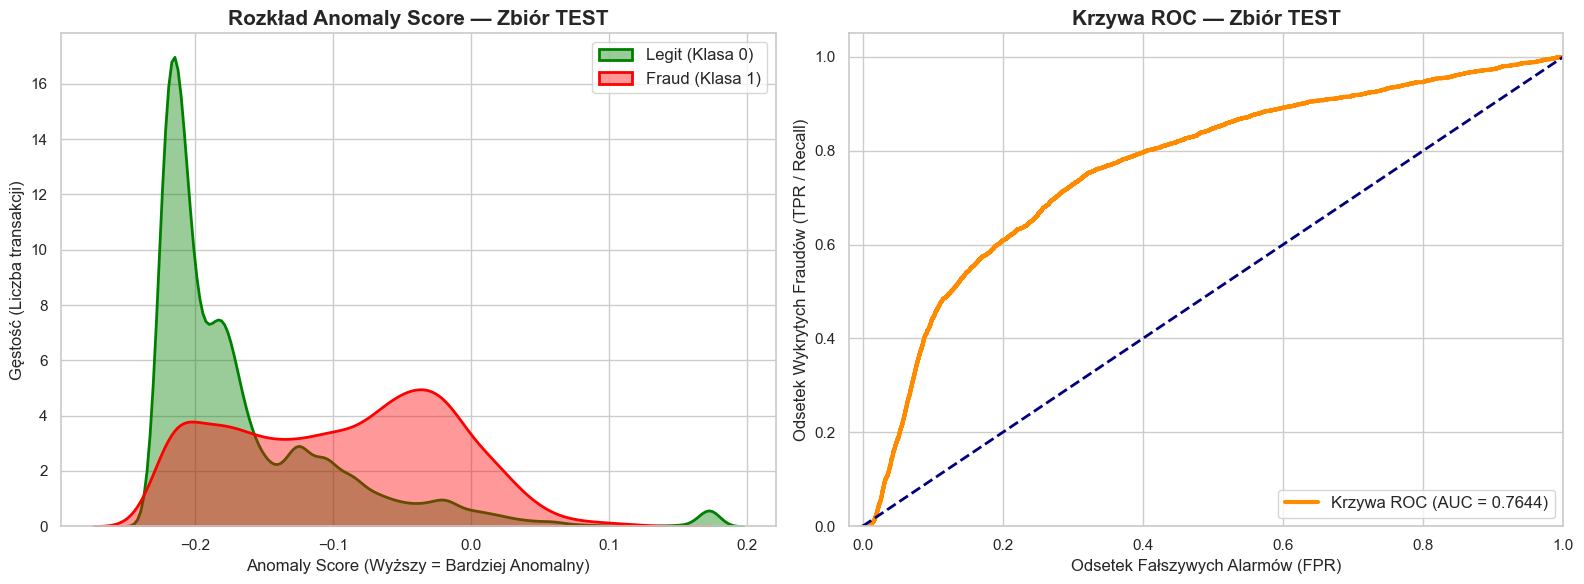

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import numpy as np

# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid", palette="muted")

def plot_anomaly_scores_and_roc(y_true, scores, dataset_name="Test"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Wykres 1 - Rozkład gęstości
    ax1 = axes[0]
    
    # wyniki (scores) osobno dla zdrowych transakcji i fraudów
    scores_legit = scores[y_true == 0]
    scores_fraud = scores[y_true == 1]
    
    # rozkłady Kernel Density Estimation
    sns.kdeplot(scores_legit, ax=ax1, color="green", fill=True, label="Legit (Klasa 0)", alpha=0.4, linewidth=2)
    sns.kdeplot(scores_fraud, ax=ax1, color="red", fill=True, label="Fraud (Klasa 1)", alpha=0.4, linewidth=2)
    
    ax1.set_title(f"Rozkład Anomaly Score — Zbiór {dataset_name}", fontsize=15, fontweight='bold')
    ax1.set_xlabel("Anomaly Score (Wyższy = Bardziej Anomalny)", fontsize=12)
    ax1.set_ylabel("Gęstość (Liczba transakcji)", fontsize=12)
    ax1.legend(fontsize=12)
    
    # Wykres 2 - Krzywa ROC
    ax2 = axes[1]
    
    # punkty krzywej ROC
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    
    # krzywa ROC
    ax2.plot(fpr, tpr, color='darkorange', lw=3, label=f'Krzywa ROC (AUC = {roc_auc:.4f})')
    # linia losowego wyboru (baseline)
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    ax2.set_xlim([-0.02, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Odsetek Fałszywych Alarmów (FPR)', fontsize=12)
    ax2.set_ylabel('Odsetek Wykrytych Fraudów (TPR / Recall)', fontsize=12)
    ax2.set_title(f"Krzywa ROC — Zbiór {dataset_name}", fontsize=15, fontweight='bold')
    ax2.legend(loc="lower right", fontsize=12)
    
    plt.tight_layout()
    plt.show()

# funkcja dla zbioru testowego
print("Generowanie wizualizacji dla zbioru TESTOWEGO...")
plot_anomaly_scores_and_roc(y_test, scores_test, "TEST")

In [6]:
from sklearn.model_selection import ParameterGrid
import time
import gc  # moduł do ręcznego czyszczenia pamięci RAM

# STROJENIE HIPERPARAMETRÓW
param_grid = {
    'n_estimators': [200, 400],
    'max_samples': [256, 512, 1024],
    'max_features': [0.8, 0.7]
}

grid = ParameterGrid(param_grid)
best_auc = 0
best_params = None

print(f"Rozpoczynam strojenie hiperparametrów ({len(grid)} kombinacji)...\n")

for i, params in enumerate(grid, 1):
    start_time = time.time()
    
    model_tuning = IsolationForest(
        n_estimators=params['n_estimators'],
        max_samples=params['max_samples'],
        max_features=params['max_features'],
        random_state=123,
        n_jobs=2  
    )
    
    model_tuning.fit(X_train)
    
    scores_valid_tune = -model_tuning.decision_function(X_valid)
    auc_score = roc_auc_score(y_valid, scores_valid_tune)
    
    elapsed = time.time() - start_time
    
    print(f"[{i}/{len(grid)}] Parametry: {params} | Valid AUC: {auc_score:.4f} | Czas: {elapsed:.1f}s")
    
    if auc_score > best_auc:
        best_auc = auc_score
        best_params = params
        
    del model_tuning
    gc.collect()

print("\n==================================================")
print(f"🏆 NAJLEPSZE ZNALEZIONE PARAMETRY:")
print(f"Parametry: {best_params}")
print(f"Najwyższy ROC-AUC na zbiorze walidacyjnym: {best_auc:.4f}")
print("==================================================")

Rozpoczynam strojenie hiperparametrów (12 kombinacji)...

[1/12] Parametry: {'max_features': 0.8, 'max_samples': 256, 'n_estimators': 200} | Valid AUC: 0.7801 | Czas: 34.2s
[2/12] Parametry: {'max_features': 0.8, 'max_samples': 256, 'n_estimators': 400} | Valid AUC: 0.7770 | Czas: 68.2s
[3/12] Parametry: {'max_features': 0.8, 'max_samples': 512, 'n_estimators': 200} | Valid AUC: 0.7788 | Czas: 34.9s
[4/12] Parametry: {'max_features': 0.8, 'max_samples': 512, 'n_estimators': 400} | Valid AUC: 0.7769 | Czas: 68.5s
[5/12] Parametry: {'max_features': 0.8, 'max_samples': 1024, 'n_estimators': 200} | Valid AUC: 0.7722 | Czas: 34.9s
[6/12] Parametry: {'max_features': 0.8, 'max_samples': 1024, 'n_estimators': 400} | Valid AUC: 0.7714 | Czas: 69.3s
[7/12] Parametry: {'max_features': 0.7, 'max_samples': 256, 'n_estimators': 200} | Valid AUC: 0.7761 | Czas: 30.1s
[8/12] Parametry: {'max_features': 0.7, 'max_samples': 256, 'n_estimators': 400} | Valid AUC: 0.7740 | Czas: 59.9s
[9/12] Parametry: {'

Inicjalizacja ostatecznego modelu z najlepszymi hiperparametrami...
Trenowanie ostatecznego modelu na X_train...
✓ Trening zakończony!

=== WERYFIKACJA METRYK (ZBIÓR TRENINGOWY)     ===
=== WYNIKI DLA ZBIORU: OSTATECZNY TRAIN ===
ROC-AUC Score: 0.7492

Confusion Matrix (Macierz pomyłek):
[[331427  10909]
 [ 10495   1493]]

Raport Klasyfikacji:
              precision    recall  f1-score   support

           0     0.9693    0.9681    0.9687    342336
           1     0.1204    0.1245    0.1224     11988

    accuracy                         0.9396    354324
   macro avg     0.5448    0.5463    0.5456    354324
weighted avg     0.9406    0.9396    0.9401    354324



Generowanie ostatecznych wykresów dla zbioru TRENINGOWEGO...


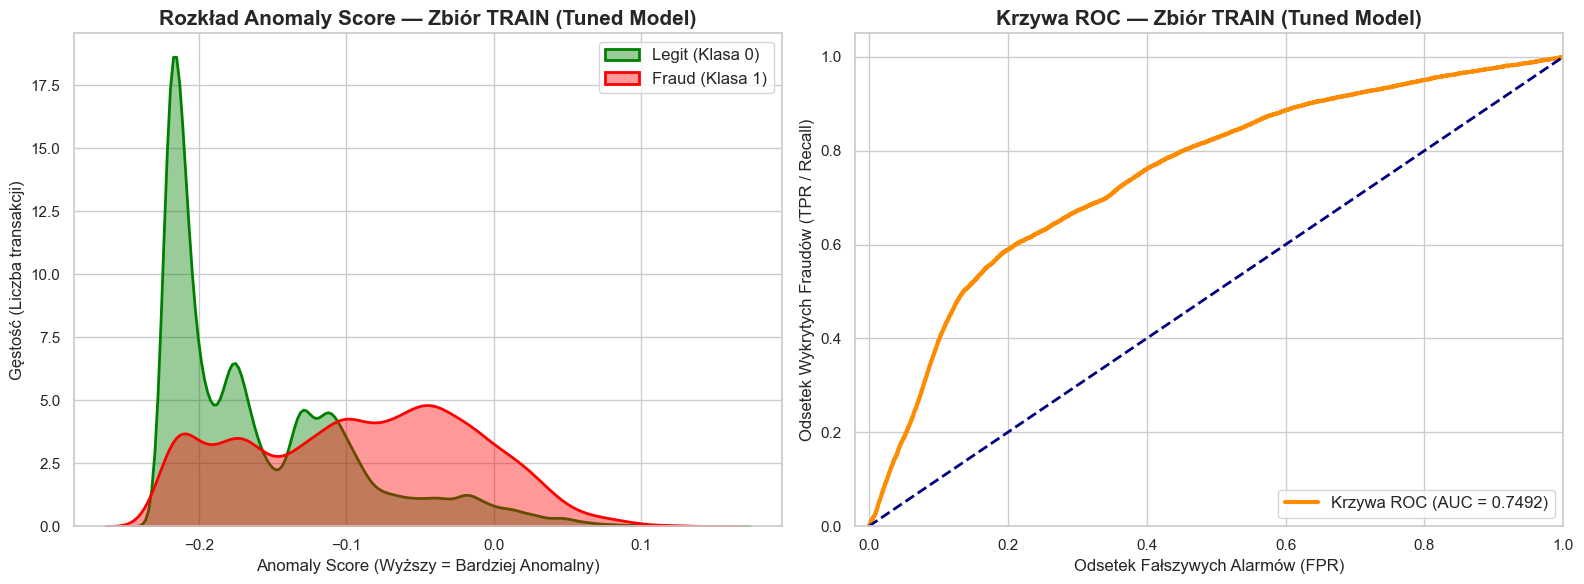

=== WERYFIKACJA METRYK (ZBIÓR WALIDACYJNY)     ===
=== WYNIKI DLA ZBIORU: OSTATECZNY VALID ===
ROC-AUC Score: 0.7801

Confusion Matrix (Macierz pomyłek):
[[110518   2979]
 [  3980    631]]

Raport Klasyfikacji:
              precision    recall  f1-score   support

           0     0.9652    0.9738    0.9695    113497
           1     0.1748    0.1368    0.1535      4611

    accuracy                         0.9411    118108
   macro avg     0.5700    0.5553    0.5615    118108
weighted avg     0.9344    0.9411    0.9376    118108



Generowanie ostatecznych wykresów dla zbioru WALIDACYJNEGO...


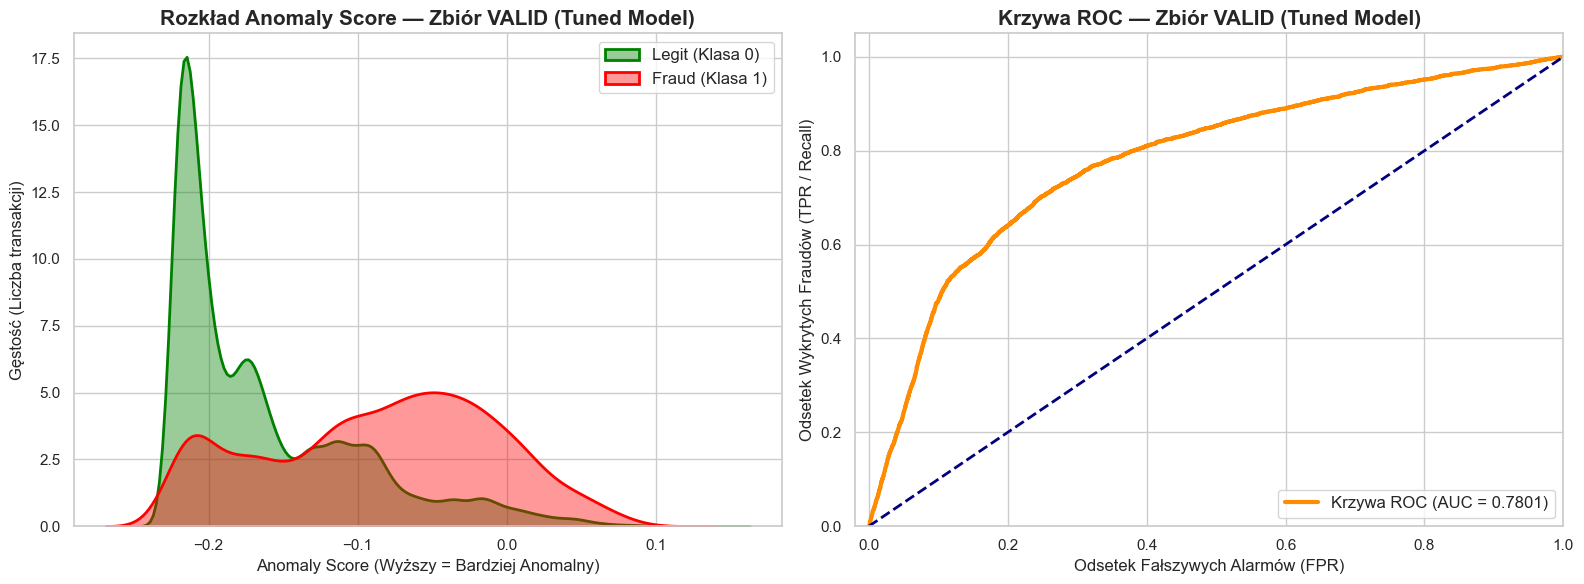


=== SCORING PRODUKCYJNY (ZBIÓR TESTOWY)        ===
Model przetwarza nowe transakcje (bez dostępu do etykiet isFraud)...

[ RAPORT OPERACYJNY DLA SYSTEMU ]
Liczba przeanalizowanych transakcji: 118,108
Transakcje uznane za NORMALNE:       113,418
Transakcje oflagowane jako FRAUD:    4,690 (3.97%)

[ DECYZJA BIZNESOWA ]:
Zgodnie z ustawionym parametrem contamination, model zablokował i skierował 4,690 najdziwniejszych transakcji do manualnej weryfikacji przez zespół analityków AML.


In [7]:
# OSTATECZNY MODEL ISOLATION FOREST

print("Inicjalizacja ostatecznego modelu z najlepszymi hiperparametrami...")
final_model = IsolationForest(
    n_estimators=200,
    max_samples=256,
    max_features=0.8,
    contamination=0.035, 
    random_state=123,
    n_jobs=2  
)

print("Trenowanie ostatecznego modelu na X_train...")
final_model.fit(X_train)
print("✓ Trening zakończony!\n")

# WERYFIKACJA JAKOŚCI NA ZBIORZE TRENINGOWYM
print("==================================================")
print("=== WERYFIKACJA METRYK (ZBIÓR TRENINGOWY)     ===")
print("==================================================")

preds_train_final, scores_train_final = evaluate_iforest(final_model, X_train, y_train, "Ostateczny TRAIN")

print("Generowanie ostatecznych wykresów dla zbioru TRENINGOWEGO...")
plot_anomaly_scores_and_roc(y_train, scores_train_final, "TRAIN (Tuned Model)")

# WERYFIKACJA JAKOŚCI NA ZBIORZE WALIDACYJNYM
print("==================================================")
print("=== WERYFIKACJA METRYK (ZBIÓR WALIDACYJNY)     ===")
print("==================================================")

preds_valid_final, scores_valid_final = evaluate_iforest(final_model, X_valid, y_valid, "Ostateczny VALID")

print("Generowanie ostatecznych wykresów dla zbioru WALIDACYJNEGO...")
plot_anomaly_scores_and_roc(y_valid, scores_valid_final, "VALID (Tuned Model)")


# SCORING NA ZBIOTZE TESTOWYM
print("\n==================================================")
print("=== SCORING PRODUKCYJNY (ZBIÓR TESTOWY)        ===")
print("==================================================")
print("Model przetwarza nowe transakcje (bez dostępu do etykiet isFraud)...")

# tylko .predict() na samych cechach (X)
test_preds_raw = final_model.predict(X_test)
# Mapowanie -1 (Anomalia) -> 1 (Fraud), 1 (Normalne) -> 0 (Legit)
test_preds_mapped = np.where(test_preds_raw == -1, 1, 0)

# Obliczenia do podsumowania
total_test_transactions = len(test_preds_mapped)
flagged_as_fraud = test_preds_mapped.sum()
percentage_flagged = (flagged_as_fraud / total_test_transactions) * 100

print(f"\n[ RAPORT OPERACYJNY DLA SYSTEMU ]")
print(f"Liczba przeanalizowanych transakcji: {total_test_transactions:,}")
print(f"Transakcje uznane za NORMALNE:       {total_test_transactions - flagged_as_fraud:,}")
print(f"Transakcje oflagowane jako FRAUD:    {flagged_as_fraud:,} ({percentage_flagged:.2f}%)")

print("\n[ DECYZJA BIZNESOWA ]:")
print(f"Zgodnie z ustawionym parametrem contamination, model zablokował i skierował "
      f"{flagged_as_fraud:,} najdziwniejszych transakcji do manualnej weryfikacji przez zespół analityków AML.")